# PyTorch — L’essentiel du framework

Notebook pédagogique associé au cours en 18 slides.

**Objectifs :**
- comprendre les `Tensor` ;
- utiliser `Autograd` ;
- construire un modèle avec `nn.Module` ;
- définir un `Loss` et un `Optimizer` ;
- écrire une boucle d’apprentissage ;
- distinguer `train()` et `eval()` ;
- utiliser `Dataset` / `DataLoader` ;
- entraîner un exemple de régression et un exemple de classification ;
- sauvegarder et recharger un modèle.

## 0. Préparation

Le notebook fonctionne sur CPU. S’il existe un GPU CUDA, PyTorch pourra l’utiliser automatiquement.

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

PyTorch version: 2.14.1+cpu
CUDA disponible: False


## 1. Workflow général

Le cycle de base est :

**Données → Tensors → Modèle → Prédictions → Loss → Backward → Optimizer → Mise à jour**

In [48]:
# Pseudo-code de la logique générale
# y_pred = model(X)
# loss = criterion(y_pred, y)
# optimizer.zero_grad()
# loss.backward()
# optimizer.step()

## 2. Les Tensors

Un `Tensor` est la structure de données fondamentale de PyTorch.

In [3]:
scalar = torch.tensor(3.0)
vector = torch.tensor([1.0, 2.0, 3.0])
matrix = torch.tensor([[1.0, 2.0], [3.0, 4.0]])

print("scalar:", scalar, "shape =", scalar.shape)
print("vector:", vector, "shape =", vector.shape)
print("matrix:", matrix, "shape =", matrix.shape)
print("dtype:", matrix.dtype)
print("ndim:", matrix.ndim)

scalar: tensor(3.) shape = torch.Size([])
vector: tensor([1., 2., 3.]) shape = torch.Size([3])
matrix: tensor([[1., 2.],
        [3., 4.]]) shape = torch.Size([2, 2])
dtype: torch.float32
ndim: 2


### Manipulation de Tensors

In [5]:
x = torch.arange(12)
print("x =", x)

x2 = x.reshape(3, 4)
print("reshape(3,4):", x2)

print("Colonne 1:", x2[:, 1])
print("Ligne 0:", x2[0, :])

A = torch.tensor([[1., 2.], [3., 4.]])
B = torch.tensor([[2., 0.], [1., 2.]])
print("A @ B =", A @ B)

print("mean(A) =", A.mean())
print("sum(A) =", A.sum())

x = tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
reshape(3,4): tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
Colonne 1: tensor([1, 5, 9])
Ligne 0: tensor([0, 1, 2, 3])
A @ B = tensor([[ 4.,  4.],
        [10.,  8.]])
mean(A) = tensor(2.5000)
sum(A) = tensor(10.)


## 3. CPU, GPU et `device`

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé:", device)

x = torch.tensor([1.0, 2.0, 3.0]).to(device)
print("x.device =", x.device)

Device utilisé: cpu
x.device = cpu


## 4. Autograd

`Autograd` calcule automatiquement les dérivées à partir du graphe de calcul.

In [13]:
x = torch.tensor(2.0)
w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

y = w * x + b
loss = (y - 10) ** 2

loss.backward()

print("y =", y.item())
print("loss =", loss.item())
print("dLoss/dw =", w.grad.item())
print("dLoss/db =", b.grad.item())

y = 7.0
loss = 9.0
dLoss/dw = -12.0
dLoss/db = -6.0


In [14]:
import torch

x = torch.tensor(2.0)
w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

y = w * x + b
loss = (y - 10) ** 2

dw, db = torch.autograd.grad(loss, (w, b))

print("y =", y.item())
print("loss =", loss.item())
print("dLoss/dw =", dw.item())
print("dLoss/db =", db.item())

y = 7.0
loss = 9.0
dLoss/dw = -12.0
dLoss/db = -6.0


### Vérification analytique

Ici :

\[
y = wx+b
\]

et

\[
L=(y-10)^2
\]

Donc :

\[

rac{\partial L}{\partial w}=2(y-10)x
\]

\[

rac{\partial L}{\partial b}=2(y-10)
\]

In [15]:
y_val = (3.0 * 2.0 + 1.0)
dL_dw = 2 * (y_val - 10) * 2.0
dL_db = 2 * (y_val - 10)
print(dL_dw, dL_db)

-12.0 -6.0


## 5. Un neurone avec `nn.Linear`

Un neurone linéaire calcule essentiellement :

\[
z = \sum_i w_i x_i + b
\]

In [16]:
model = nn.Linear(3, 1)
x = torch.tensor([[1.0, 2.0, 3.0]])
y = model(x)

print("Sortie:", y)
print("Poids:", model.weight)
print("Biais:", model.bias)

Sortie: tensor([[1.0545]], grad_fn=<AddmmBackward0>)
Poids: Parameter containing:
tensor([[ 0.4965, -0.0437,  0.3196]], requires_grad=True)
Biais: Parameter containing:
tensor([-0.3136], requires_grad=True)


In [22]:
import os
import sys

# 1. On injecte le dossier de Graphviz tout en haut du PATH de Windows pour cette session
graphviz_bin_dir = r"C:\Program Files\Graphviz\bin"
if graphviz_bin_dir not in os.environ["PATH"]:
    os.environ["PATH"] = graphviz_bin_dir + os.pathsep + os.environ["PATH"]

# 2. Vos imports habituels
import torch
import torch.nn as nn
from torchviz import make_dot

# 3. Création du modèle et calcul
model = nn.Linear(3, 1)
x = torch.tensor([[1.0, 2.0, 3.0]])
y = model(x)

# 4. Génération et rendu du graphe
dot = make_dot(y, params=dict(model.named_parameters()))
dot.render("graphe_operations", format="png", cleanup=True)

print("Succès ! Le fichier 'graphe_operations.png' a été généré.")


Succès ! Le fichier 'graphe_operations.png' a été généré.


In [24]:
import torch
import torch.nn as nn
from torchviz import make_dot

model = nn.Linear(3, 1)
x = torch.tensor([[1.0, 2.0, 3.0]])
y = model(x)

print("Sortie:", y)
print("Poids:", model.weight)
print("Biais:", model.bias)

dot = make_dot(y, params=dict(model.named_parameters()))
dot.render("graphe_operations", format="png", cleanup=True)

Sortie: tensor([[-1.7227]], grad_fn=<AddmmBackward0>)
Poids: Parameter containing:
tensor([[ 0.2124, -0.1626, -0.5349]], requires_grad=True)
Biais: Parameter containing:
tensor([-0.0051], requires_grad=True)


'graphe_operations.png'

## 6. Construire un réseau avec `nn.Module`

In [25]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 3)
        )

    def forward(self, x):
        return self.net(x)

model = MLP()
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=3, bias=True)
  )
)


In [26]:
model = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 3)
        )
print(model)

Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=3, bias=True)
)


## 7. Fonctions d’activation

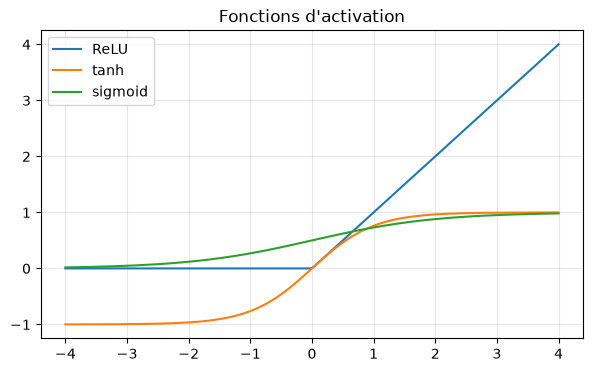

In [43]:
x = torch.linspace(-4, 4, 200)
relu = torch.relu(x)
tanh = torch.tanh(x)
sigmoid = torch.sigmoid(x)

plt.figure(figsize=(7,4))
plt.plot(x.tolist(), relu.tolist(), label='ReLU')
plt.plot(x.tolist(), tanh.tolist(), label='tanh')
plt.plot(x.tolist(), sigmoid.tolist(), label='sigmoid')
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Fonctions d'activation")
plt.show()

## 8. Forward propagation

L’appel `model(X)` déclenche automatiquement `model.forward(X)`.

In [36]:
X = torch.randn(5, 4)
# L’appel model(X) déclenche automatiquement model.forward(X)
predicted = model(X)
print("Shape entrée :", X.shape)
print("Shape sortie :", predicted.shape)

Shape entrée : torch.Size([5, 4])
Shape sortie : torch.Size([5, 3])


## 9. Fonctions de coût

Cas principaux :
- régression : `nn.MSELoss()` ;
- classification multi-classe : `nn.CrossEntropyLoss()` ;
- classification binaire : `nn.BCEWithLogitsLoss()`.

In [37]:
# Régression
criterion_reg = nn.MSELoss()
y_pred = torch.tensor([[2.0], [4.0]])
y_true = torch.tensor([[3.0], [5.0]])
print("MSE =", criterion_reg(y_pred, y_true).item())

# Classification multi-classe
criterion_cls = nn.CrossEntropyLoss()
pred = torch.tensor([[2.0, 1.0, 0.5], [0.2, 0.1, 2.0]])
y = torch.tensor([0, 2])
print("CrossEntropy =", criterion_cls(pred, y).item())

MSE = 1.0
CrossEntropy = 0.36905235052108765


## 10. Optimizers

L’optimiseur utilise les gradients pour mettre à jour les paramètres.

In [38]:
simple_model = nn.Linear(1, 1)
optimizer = torch.optim.Adam(simple_model.parameters(), lr=1e-2)
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


## 11. La boucle d’apprentissage

C’est le cœur de PyTorch.

In [39]:
X = torch.randn(8, 1)
y = 2 * X + 1
simple_model = nn.Linear(1, 1)
optimizer = torch.optim.Adam(simple_model.parameters(), lr=1e-2)
criterion = nn.MSELoss()
epochs = 500
# Exemple générique
for epoch in range(epochs):
    simple_model.train()
    y_pred = simple_model(X)
    loss = criterion(y_pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 100 ==0 : 
        print(f"epoch={epoch} loss={loss.item():.4f}")

epoch=0 loss=4.7929
epoch=100 loss=0.8970
epoch=200 loss=0.1166
epoch=300 loss=0.0098
epoch=400 loss=0.0004


## 12. `train()` vs `eval()`

`model.train()` et `model.eval()` influencent notamment le comportement de `Dropout` et `BatchNorm`.

`eval()` ne désactive pas le calcul des gradients. Pour l’inférence, on utilise généralement `torch.inference_mode()`.

In [40]:
class DropoutDemo(nn.Module):
    def __init__(self):
        super().__init__()
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        return self.dropout(x)

m = DropoutDemo()
x = torch.ones(10)

m.train()
print("train() :", m(x))

m.eval()
with torch.inference_mode():
    print("eval()  :", m(x))

train() : tensor([0., 2., 2., 2., 0., 0., 2., 0., 2., 2.])
eval()  : tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])


## 13. Dataset et DataLoader

In [41]:
X = torch.randn(100, 3)
y = torch.randn(100, 1)

dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

for X_batch, y_batch in loader:
    print("Batch X:", X_batch.shape, "Batch y:", y_batch.shape)
    break

Batch X: torch.Size([16, 3]) Batch y: torch.Size([16, 1])


# Partie pratique 1 — Régression linéaire

Nous générons des données proches de :

\[
y = 3x + 2 + bruit
\]

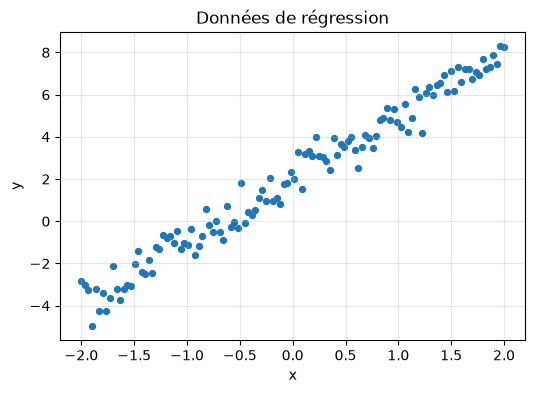

In [44]:
torch.manual_seed(42)

X = torch.linspace(-2, 2, 120).unsqueeze(1)
noise = 0.6 * torch.randn_like(X)
y = 3 * X + 2 + noise

plt.figure(figsize=(6,4))
plt.scatter(X.tolist(), y.tolist(), s=18)
plt.title("Données de régression")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.show()

## 14. Modèle, loss et optimizer

In [45]:
model_reg = nn.Linear(1, 1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_reg.parameters(), lr=0.05)

## 15. Entraînement de la régression

In [46]:
losses = []

for epoch in range(300):
    model_reg.train()

    y_pred = model_reg(X)
    loss = criterion(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

print("Dernier loss:", losses[-1])
print("w appris:", model_reg.weight.item())
print("b appris:", model_reg.bias.item())

Dernier loss: 0.3438417613506317
w appris: 2.9894580841064453
b appris: 2.030014991760254


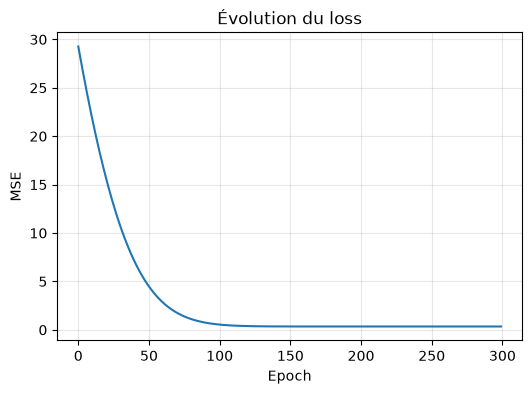

In [47]:
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Évolution du loss")
plt.grid(True, alpha=0.3)
plt.show()

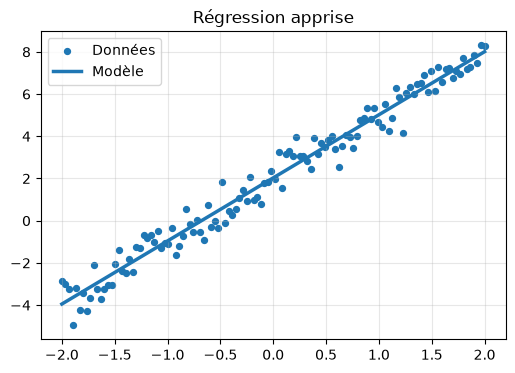

In [49]:
model_reg.eval()
with torch.inference_mode():
    y_hat = model_reg(X)

plt.figure(figsize=(6,4))
plt.scatter(X.tolist(), y.tolist(), s=18, label="Données")
plt.plot(X.tolist(), y_hat.tolist(), linewidth=2.5, label="Modèle")
plt.legend()
plt.title("Régression apprise")
plt.grid(True, alpha=0.3)
plt.show()

In [51]:
ss_res = torch.sum((y - y_hat) ** 2)
ss_tot = torch.sum((y - y.mean()) ** 2)
r2 = 1 - ss_res / ss_tot
print(f"R2 Score = {r2.item():.3f}")

R2 Score = 0.972


# Partie pratique 2 — Classification

Créons deux classes de points en 2D.

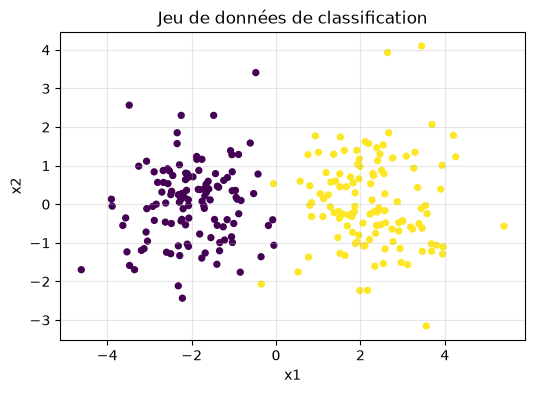

In [53]:
torch.manual_seed(0)

n = 120
class0 = torch.randn(n, 2) + torch.tensor([-2.0, 0.0])
class1 = torch.randn(n, 2) + torch.tensor([ 2.0, 0.0])

X_cls = torch.cat([class0, class1], dim=0)
y_cls = torch.cat([
    torch.zeros(n, dtype=torch.long),
    torch.ones(n, dtype=torch.long)
])

plt.figure(figsize=(6,4))
plt.scatter(X_cls[:,0].tolist(), X_cls[:,1].tolist(), c=y_cls.tolist(), s=18)
plt.title("Jeu de données de classification")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True, alpha=0.3)
plt.show()

## 16. Modèle de classification

In [54]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        return self.net(x)

model_cls = Classifier()
criterion_cls = nn.CrossEntropyLoss()
optimizer_cls = torch.optim.Adam(model_cls.parameters(), lr=0.01)

## 17. Entraînement de la classification

In [55]:
losses_cls = []

for epoch in range(250):
    model_cls.train()

    logits = model_cls(X_cls)
    loss = criterion_cls(logits, y_cls)

    optimizer_cls.zero_grad()
    loss.backward()
    optimizer_cls.step()

    losses_cls.append(loss.item())

print("Dernier loss:", losses_cls[-1])

Dernier loss: 0.0006943688495084643


In [56]:
model_cls.eval()
with torch.inference_mode():
    logits = model_cls(X_cls)
    pred = logits.argmax(dim=1)
    accuracy = (pred == y_cls).float().mean()

print(f"Accuracy = {accuracy.item()*100:.2f}%")

Accuracy = 100.00%


Accuracy = 1.0000, recall = 1.0000, precision = 1.0000, f1score = 1.0000
tensor([[120,   0],
        [  0, 120]])


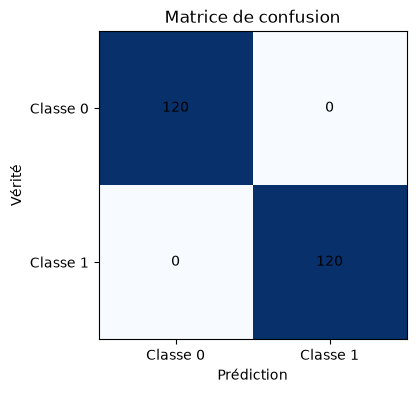

In [57]:
true_positive = ((pred == 1) & (y_cls == 1)).sum().float()
false_positive = ((pred == 1) & (y_cls == 0)).sum().float()
false_negative = ((pred == 0) & (y_cls == 1)).sum().float()

accuracy_value = (pred == y_cls).float().mean()
recall_value = true_positive / (true_positive + false_negative)
precision_value = true_positive / (true_positive + false_positive)
f1_score_value = 2 * precision_value * recall_value / (precision_value + recall_value)

print(f"Accuracy = {accuracy_value:.4f}, recall = {recall_value:.4f}, precision = {precision_value:.4f}, f1score = {f1_score_value:.4f}")

confusion_matrix = torch.bincount(2 * y_cls + pred, minlength=4).reshape(2, 2)
print(confusion_matrix)

plt.figure(figsize=(4, 4))
plt.imshow(confusion_matrix.tolist(), cmap="Blues")
plt.xticks([0, 1], ["Classe 0", "Classe 1"])
plt.yticks([0, 1], ["Classe 0", "Classe 1"])
plt.xlabel("Prédiction")
plt.ylabel("Vérité")
plt.title("Matrice de confusion")
for row in range(2):
    for column in range(2):
        plt.text(column, row, str(confusion_matrix[row, column].item()), ha="center", va="center")
plt.show()

## Visualisation de la frontière de décision

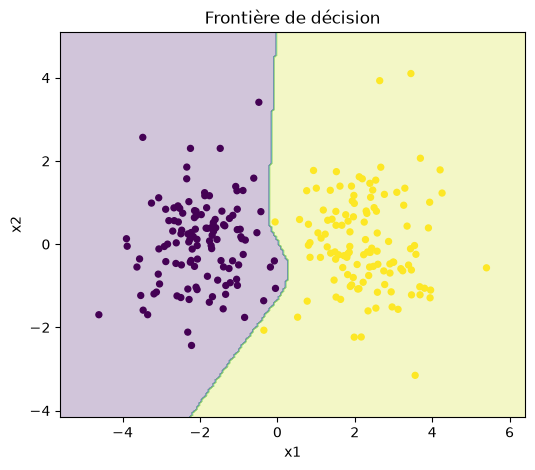

In [58]:
x1_min, x1_max = X_cls[:,0].min()-1, X_cls[:,0].max()+1
x2_min, x2_max = X_cls[:,1].min()-1, X_cls[:,1].max()+1

xx1, xx2 = torch.meshgrid(
    torch.linspace(x1_min, x1_max, 200),
    torch.linspace(x2_min, x2_max, 200),
    indexing='ij'
)

grid = torch.stack([xx1.reshape(-1), xx2.reshape(-1)], dim=1)

model_cls.eval()
with torch.inference_mode():
    zz = model_cls(grid).argmax(dim=1).reshape(xx1.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx1.tolist(), xx2.tolist(), zz.tolist(), alpha=0.25)
plt.scatter(X_cls[:,0].tolist(), X_cls[:,1].tolist(), c=y_cls.tolist(), s=18)
plt.title("Frontière de décision")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

## 18. Sauvegarder et recharger un modèle

In [59]:
path = "classifier_state_dict.pt"
torch.save(model_cls.state_dict(), path)
print("Modèle sauvegardé dans", path)

new_model = Classifier()
new_model.load_state_dict(torch.load(path, weights_only=True))
new_model.eval()

with torch.inference_mode():
    pred_new = new_model(X_cls).argmax(dim=1)

print("Prédictions identiques:", torch.equal(pred, pred_new))

Modèle sauvegardé dans classifier_state_dict.pt
Prédictions identiques: True


# Synthèse

Les briques essentielles de PyTorch sont maintenant en place :

1. `Tensor`
2. `nn.Module`
3. `forward()`
4. fonction de coût
5. `optimizer.zero_grad()`
6. `loss.backward()`
7. `optimizer.step()`
8. `train()` / `eval()`
9. `Dataset` / `DataLoader`
10. sauvegarde avec `state_dict()`

Cette mécanique reste pratiquement la même pour des modèles plus avancés : CNN, Transformers, modèles génératifs ou PINNs.

# Exercices